In [1]:
import os
import pickle
import mlflow
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

from tqdm import tqdm
from numpy import sort
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier, plot_importance
from sklearn.ensemble import RandomForestClassifier
from mlflow.models.signature import infer_signature
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import scale, StandardScaler
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

In [ ]:
data_path = '/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/features_data_main/two_class_raw_1s_no.csv'
features = pd.read_csv(data_path)
features.drop(['center_time', 'start_time', 'end_time'], axis=1, inplace=True)

In [3]:
X = features.drop(columns=['label', 'experiment_id'])
y = features['label']

In [4]:
X = features.drop(columns=['label', 'experiment_id'])
y = features['label']
groups = features['experiment_id']

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]

In [5]:
label_encoder = LabelEncoder()
# Encode y_test and y_train
y_train_encoded = label_encoder.fit_transform(y_train) 
y_test_encoded = label_encoder.transform(y_test)

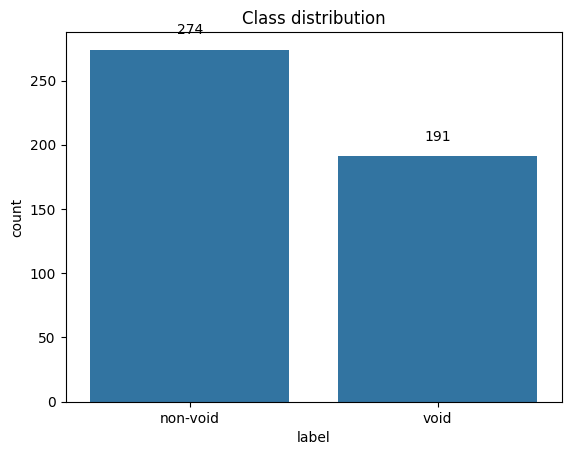

In [6]:
plt.figure()
ax = sns.countplot(x='label',
                   data=features,
                   order=features.label.value_counts().index)

# Manually add value labels
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 10,
            f'{int(height)}',
            ha='center', va='bottom')

plt.title('Class distribution')
plt.show()

In [7]:
# Fit initial model
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train_encoded)


# make predictions for test data and evaluate
rf_predictions = label_encoder.inverse_transform(rf_model.predict(X_test))
accuracy = accuracy_score(y_test, rf_predictions)
print("Accuracy: %.2f%%" % (accuracy * 100.0))

Accuracy: 72.58%


In [8]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Train model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
# rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10, min_samples_split=5, min_samples_leaf=2)
rf.fit(X_train, y_train_encoded)

# Calculate accuracies
train_acc = accuracy_score(y_train_encoded, rf.predict(X_train))
val_acc = accuracy_score(y_test_encoded, rf.predict(X_test))

print(f"Training Accuracy: {train_acc:.3f}")
print(f"Validation Accuracy: {val_acc:.3f}")
print(f"Gap: {train_acc - val_acc:.3f}")

# Rule of thumb: Gap > 0.05-0.10 might indicate overfitting
if train_acc - val_acc > 0.10:
    print("⚠️  Potential overfitting detected!")

Training Accuracy: 1.000
Validation Accuracy: 0.726
Gap: 0.274
⚠️  Potential overfitting detected!


In [9]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, oob_score=True)
# rf = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42, max_depth=10, min_samples_split=5, min_samples_leaf=2)
rf.fit(X_train, y_train_encoded)

train_acc = rf.score(X_train, y_train_encoded)
oob_acc = rf.oob_score_
val_acc = rf.score(X_test, y_test_encoded)

print(f"Training Accuracy: {train_acc:.3f}")
print(f"OOB Accuracy: {oob_acc:.3f}")
print(f"Validation Accuracy: {val_acc:.3f}")

# OOB should be close to validation accuracy
# Large gap between training and OOB indicates overfitting

Training Accuracy: 1.000
OOB Accuracy: 0.724
Validation Accuracy: 0.726


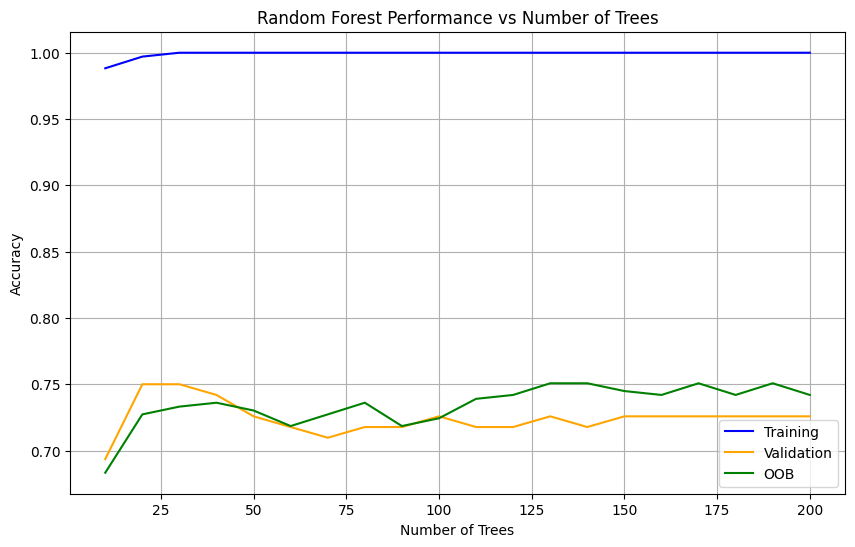

In [10]:
train_scores = []
val_scores = []
oob_scores = []
tree_counts = range(10, 201, 10)

for n_trees in tree_counts:
    rf = RandomForestClassifier(n_estimators=n_trees, oob_score=True, random_state=42)
    rf.fit(X_train, y_train_encoded)
    
    train_scores.append(rf.score(X_train, y_train_encoded))
    val_scores.append(rf.score(X_test, y_test_encoded))
    oob_scores.append(rf.oob_score_)

plt.figure(figsize=(10, 6))
plt.plot(tree_counts, train_scores, label='Training', color='blue')
plt.plot(tree_counts, val_scores, label='Validation', color='orange')
plt.plot(tree_counts, oob_scores, label='OOB', color='green')
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.title('Random Forest Performance vs Number of Trees')
plt.legend()
plt.grid(True)
plt.show()

# Signs of overfitting:
# 1. Training accuracy keeps increasing while validation plateaus/decreases
# 2. Growing gap between training and validation curves

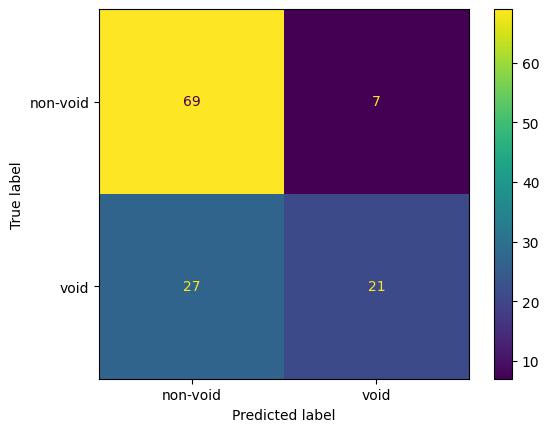

In [11]:
cm = confusion_matrix(y_test, rf_predictions)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['non-void', 'void'])
cm_display.plot()
plt.show()

In [12]:
from sklearn.model_selection import cross_val_score
# Perform cross-validation
gkf = GroupKFold(n_splits=10)
cv_scores = cross_val_score(RandomForestClassifier(random_state=42), X, label_encoder.transform(y), groups=groups, cv=gkf, scoring='accuracy')
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {np.mean(cv_scores) * 100:.2f}%")
print(f"Standard deviation of CV accuracy: {np.std(cv_scores) * 100:.2f}%")
print(f"Variance of CV accuracy: {np.var(cv_scores) * 100:.2f}%")

Cross-validation scores: [0.82222222 0.82       0.8        0.66       0.70454545 0.61363636
 0.43181818 0.65909091 0.84       0.75510204]
Mean CV accuracy: 71.06%
Standard deviation of CV accuracy: 11.98%
Variance of CV accuracy: 1.44%
